<a href="https://colab.research.google.com/github/Grashch/Kaggle_tasks/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Feature Engineering**

В этом курсе вы узнаете об одном из важнейших шагов на пути к созданию отличной модели машинного обучения: проектировании признаков. Вы научитесь:

*   определять, какие признаки являются наиболее важными, используя взаимную информацию;
*   создавать новые признаки в нескольких реальных предметных областях;
кодировать категориальные значения с высокой кардинальностью с помощью целевого кодирования;
*   создавать признаки сегментации с помощью кластеризации k-средних;
*   разлагать вариативность набора данных на признаки с помощью анализа главных компонентов.

Практические упражнения завершатся созданием полного блокнота, в котором все эти методы будут применены для участия в конкурсе House Prices Getting Started. После завершения курса у вас будет несколько идей, которые вы сможете использовать для дальнейшего улучшения своих результатов.

# **Цель разработки функциональных возможностей**
Цель инженерии признаков — просто сделать ваши данные более подходящими для решения поставленной задачи.
Рассмотрим показатели «ощущаемой температуры», такие как индекс жары и ветровое охлаждение. Эти величины пытаются измерить температуру, воспринимаемую человеком, на основе температуры воздуха, влажности и скорости ветра — параметров, которые мы можем измерить напрямую. Можно рассматривать ощущаемую температуру как результат своего рода инженерии признаков, попытку сделать наблюдаемые данные более релевантными тому, что нас действительно волнует: как на самом деле ощущается температура на улице!
Вы можете использовать инженерию признаков для:
*   улучшения прогностической эффективности модели;
*   снижения вычислительных или информационных потребностей;
*   улучшения интерпретируемости результатов.

# **Основной принцип инженерии признаков**

Чтобы признак был полезен, он должен иметь связь с целевым значением, которую ваша модель способна изучить. Линейные модели, например, способны изучать только линейные зависимости. Поэтому при использовании линейной модели ваша цель — преобразовать признаки, чтобы сделать их связь с целевым значением линейной.

Ключевая идея здесь заключается в том, что преобразование, которое вы применяете к признаку, по сути, становится частью самой модели. Допустим, вы пытаетесь предсказать цену квадратных участков земли на основе длины одной стороны. Подгонка линейной модели непосредственно к длине дает плохие результаты: связь не является линейной.
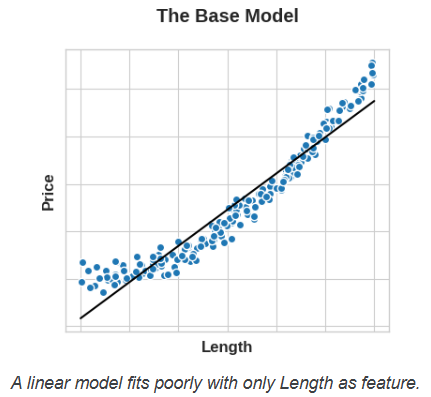

Однако, если мы возведем в квадрат функцию «Длина», чтобы получить «Площадь», мы создадим линейную зависимость. Добавление «Площади» к набору функций означает, что эта линейная модель теперь может аппроксимировать параболу. Другими словами, возведение функции в квадрат дает линейной модели возможность аппроксимировать функции, возведенные в квадрат.

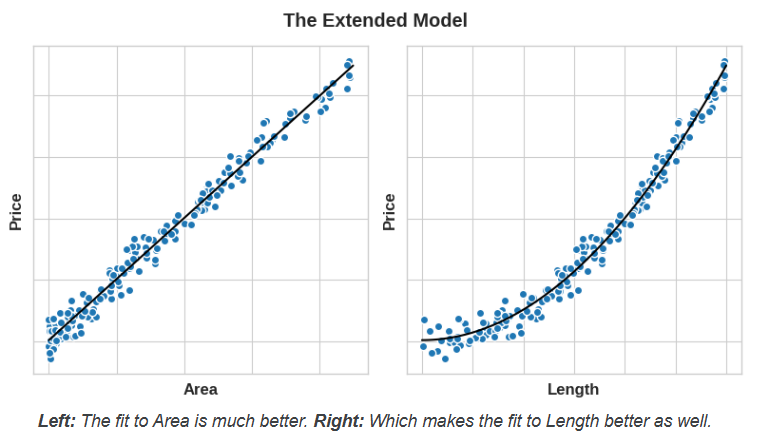

Это должно показать вам, почему время, затраченное на разработку признаков, может быть настолько эффективным. Какие бы взаимосвязи ваша модель не могла изучить самостоятельно, вы можете восстановить их с помощью преобразований. При разработке набора признаков подумайте о том, какую информацию ваша модель могла бы использовать для достижения наилучших результатов.

# **Пример — Состав бетона**

Чтобы проиллюстрировать эти идеи, мы увидим, как добавление нескольких синтетических признаков к набору данных может улучшить прогностическую эффективность модели случайного леса.

Набор данных «Бетон» https://www.kaggle.com/sinamhd9/concrete-comprehensive-strength содержит различные составы бетона и прочность на сжатие полученного продукта, которая является мерой того, какую нагрузку может выдержать данный вид бетона. Задача для этого набора данных — предсказать прочность бетона на сжатие, исходя из его состава.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

df = pd.read_excel('/content/Concrete_Data.xls')
df.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


Здесь вы можете увидеть различные ингредиенты, входящие в состав каждого вида бетона. Через мгновение мы увидим, как добавление некоторых дополнительных синтетических признаков, полученных из этих ингредиентов, может помочь модели изучить важные взаимосвязи между ними.

Сначала мы установим базовый уровень, обучив модель на неаугментированном наборе данных. Это поможет нам определить, действительно ли наши новые признаки полезны.

Установление таких базовых уровней — хорошая практика на начальном этапе процесса проектирования признаков. Базовая оценка может помочь вам решить, стоит ли сохранять ваши новые признаки или следует отбросить их и, возможно, попробовать что-то другое.

In [ ]:
X = df.copy()
y = X.pop('CompressiveStrength')

baseline = RandomForestRegressor(criterion='absolute_error', random_state=0)
baseline_score = cross_val_score(
    baseline, X, y, cv=5, scoring='neg_mean_absolute_error'
)
baseline_score = -1 * baseline_score.mean()

print(f'MAE Baseline Score: {baseline_score:.4}')

MAE Baseline Score: 8.397


Если вы когда-либо готовили дома, вы, вероятно, знаете, что соотношение ингредиентов в рецепте обычно лучше предсказывает конечный результат, чем их абсолютное количество. Таким образом, можно предположить, что соотношения указанных выше характеристик будут хорошим предиктором прочности на сжатие.

Ячейка ниже добавляет в набор данных три новых характеристики соотношения.

In [ ]:
X['FCRatio'] = X['FineAggregate'] / X['CoarseAggregate']
X['AggCmtRatio'] = (X['CoarseAggregate'] + X['FineAggregate']) / X['Cement']
X['WtrCmtRatio'] = X['Water'] / X['Cement']

model = RandomForestRegressor(criterion="absolute_error", random_state=0)
score = cross_val_score(
    model, X, y, cv=5, scoring="neg_mean_absolute_error"
)
score = -1 * score.mean()

print(f"MAE Score with Ratio Features: {score:.4}")

MAE Score with Ratio Features: 8.011


И действительно, производительность улучшилась! Это свидетельствует о том, что новые характеристики соотношения выявили для модели важную информацию, которую она раньше не обнаруживала.

# **Взаимная информация**
# *Найдите объекты с наибольшим потенциалом.*

# Введение
Первое знакомство с новым набором данных иногда может показаться ошеломляющим. Вам могут быть представлены сотни или тысячи признаков без какого-либо описания. С чего же начать?

Отличным первым шагом является построение ранжирования с использованием метрики полезности признаков — функции, измеряющей взаимосвязь между признаком и целевой функцией. Затем вы можете выбрать меньший набор наиболее полезных признаков для первоначальной разработки и быть более уверенными в том, что ваше время будет потрачено с пользой.

Метрика, которую мы будем использовать, называется «взаимная информация». Взаимная информация во многом похожа на корреляцию тем, что измеряет взаимосвязь между двумя величинами. Преимущество взаимной информации заключается в том, что она может обнаруживать любые виды взаимосвязей, в то время как корреляция обнаруживает только линейные зависимости.

Взаимная информация — это отличная универсальная метрика, особенно полезная на начальном этапе разработки признаков, когда вы еще не знаете, какую модель хотите использовать. Она:

*   проста в использовании и интерпретации,
*   вычислительно эффективна,
*   теоретически обоснована,
*   устойчива к переобучению и,
*   способна обнаруживать любые виды взаимосвязей

# **Взаимная информация и что она измеряет**

Взаимная информация описывает взаимосвязи с точки зрения неопределенности. Взаимная информация (ВИ) между двумя величинами — это мера того, насколько знание одной величины уменьшает неопределенность в отношении другой. Если бы вы знали значение характеристики, насколько увереннее вы были бы в отношении целевого значения?

Вот пример из данных Ames Housing. На рисунке показана взаимосвязь между внешним качеством дома и ценой, по которой он был продан. Каждая точка представляет собой дом.

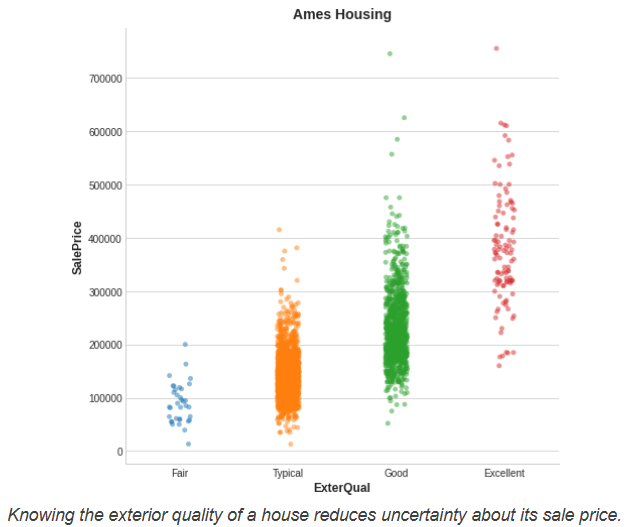

Из рисунка видно, что знание значения ExterQual должно повышать вашу уверенность в соответствующей цене продажи (SalePrice) — каждая категория ExterQual стремится сконцентрировать цену продажи в определенном диапазоне. Взаимная информация, которой обладают ExterQual и SalePrice, представляет собой среднее снижение неопределенности в SalePrice, рассчитанное по четырем значениям ExterQual. Поскольку, например, значение Fair встречается реже, чем Typical, значение Fair получает меньший вес в показателе взаимной информации.

(Техническое примечание: то, что мы называем неопределенностью, измеряется с помощью величины из теории информации, известной как «энтропия». Энтропия переменной примерно означает: «сколько вопросов типа «да» или «нет» вам потребуется задать, чтобы описать возникновение этой переменной в среднем». Чем больше вопросов вам приходится задавать, тем больше неопределенности у вас должно быть в отношении переменной. Взаимная информация — это то, на сколько вопросов, как вы ожидаете, ответит признак относительно целевого значения.)

# **Интерпретация показателей взаимной информации**

Наименьшая возможная взаимная информация между величинами равна 0,0. Когда взаимная информация равна нулю, величины независимы: ни одна из них не может ничего сказать о другой. И наоборот, теоретически нет верхнего предела для того, какой может быть взаимная информация. Однако на практике значения выше 2,0 встречаются редко. (Взаимная информация — это логарифмическая величина, поэтому она увеличивается очень медленно.)

Следующий рисунок даст вам представление о том, как значения взаимной информации соответствуют типу и степени связи признака с целевым объектом.

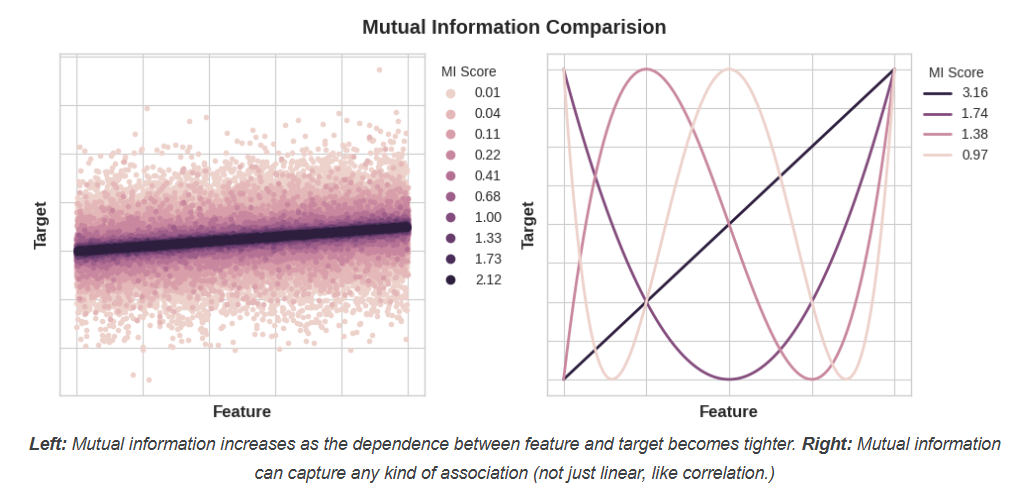

Вот несколько моментов, которые следует помнить при применении взаимной информации:

*   Взаимная информация может помочь вам понять относительный потенциал признака как предиктора целевого значения, рассматриваемого сам по себе.
*   Признак может быть очень информативным при взаимодействии с другими признаками, но не столь информативным сам по себе. Взаимная информация не может обнаружить взаимодействия между признаками. Это одномерная метрика.
*   Фактическая полезность признака зависит от модели, с которой вы его используете. Признак полезен только в той степени, в которой ваша модель может изучить его связь с целевым значением. Высокий показатель взаимной информации не означает, что ваша модель сможет что-либо сделать с этой информацией. Возможно, вам потребуется сначала преобразовать признак, чтобы выявить связь.

# **Пример — Автомобили 1985 года**
Набор данных «Автомобили» https://www.kaggle.com/toramky/automobile-dataset содержит 193 автомобиля 1985 модельного года. Цель этого набора данных — предсказать цену автомобиля (целевой показатель) на основе 23 характеристик автомобиля, таких как марка, тип кузова и мощность. В этом примере мы ранжируем характеристики с помощью взаимной информации и исследуем результаты с помощью визуализации данных.

Ячейка импортирует некоторые библиотеки и загружает набор данных.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
df = pd.read_csv('/content/Automobile_data.csv')
df = df.drop('normalized-losses', axis=1)
df = df[~(df == '?').any(axis=1)]
df.head()

,symboling,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


Алгоритм scikit-learn для обработки множественной информации обрабатывает дискретные признаки иначе, чем непрерывные. Следовательно, необходимо указать, какие из них какие. Как правило, всё, что должно иметь тип данных float, не является дискретным. Категориальные переменные (объектного или категориального типа) можно рассматривать как дискретные, указав для них кодировку метки. (Вы можете ознакомиться с кодировкой меток в нашем уроке по категориальным переменным http://www.kaggle.com/alexisbcook/categorical-variables.)

In [7]:
X = df.copy()
y = X.pop('price')

# Label encoding for categoricals
for colname in X.select_dtypes('object'):
    X[colname], _ = X[colname].factorize()

# All discrete features should now have integer dtypes (double-check this before using MI!)
discrete_features = X.dtypes == int

В модуле feature_selection библиотеки Scikit-learn есть две метрики взаимной информации: одна для вещественных целевых значений (mutual_info_regression) и одна для категориальных целевых значений (mutual_info_classif). Наше целевое значение, price, является вещественным. В следующей ячейке вычисляются оценки взаимной информации для наших признаков и они объединяются в удобный датафрейм.

In [8]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::3]  # show a few features with their MI scores

,MI Scores
curb-weight,1.580603
highway-mpg,0.950400
bore,0.699023
wheel-base,0.589931
peak-rpm,0.450479
num-of-cylinders,0.332152
engine-type,0.149994
fuel-type,0.048139


А теперь столбчатая диаграмма для упрощения сравнений:

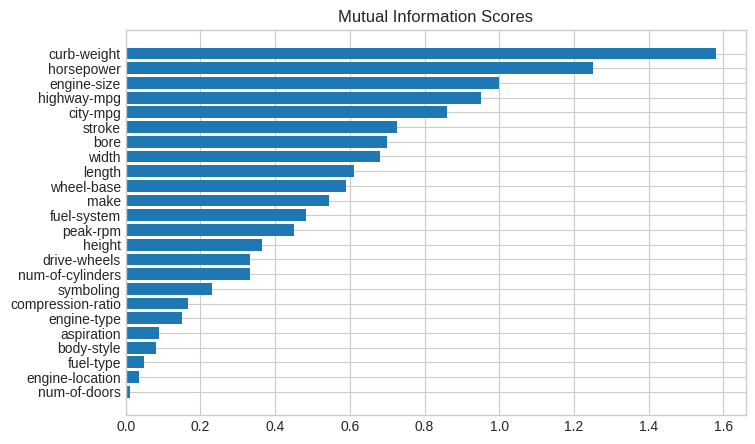

In [9]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title('Mutual Information Scores')


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

Визуализация данных — отличное дополнение к рейтингу полезности. Давайте рассмотрим несколько примеров.

Как и следовало ожидать, высоко оцененный показатель curb_weight демонстрирует сильную взаимосвязь с ценой, которая является целевым показателем.

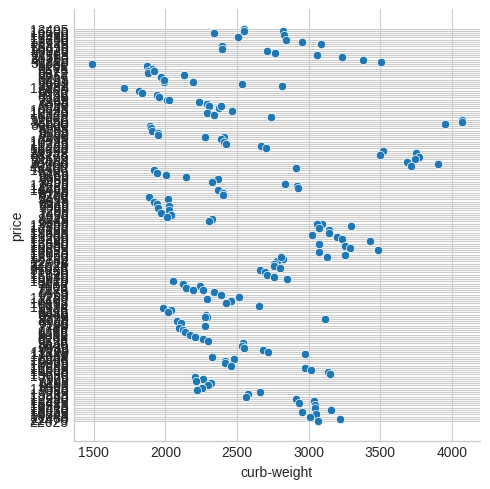

In [11]:
sns.relplot(x='curb-weight', y='price', data=df);